In [13]:
import os
import sys
current_dir = os.getcwd()
root_path = os.path.abspath(os.path.join(current_dir, '..', '..'))
if root_path not in sys.path:
    sys.path.append(root_path)
import torch
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import torch.nn as nn
import numpy as np
import pickle
import pandas as pd
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import math
import scipy.special
import random as rd
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision.models as models
from torchvision.models import VGG16_Weights
from tqdm import tqdm
import torch.optim.lr_scheduler as lr_scheduler
from python_scripts.sgr_utils import *
from python_scripts.plotting import *
from python_scripts.preprocessing import *
from scipy.special import gammaln
import warnings
warnings.filterwarnings("ignore")
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 200

print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: False


In [14]:
sgr_df = pickle.load(open('sgr_set_cnn','rb')) 
sgr_df = sgr_df.sample(frac=1, random_state=42)
print(sgr_df.shape)
sgr_df.head() 

(7000, 3)


,y_true,y_pred,SR
6500,0.0,0.0,0.929581
2944,0.0,0.0,0.982615
2024,1.0,1.0,0.542768
263,0.0,0.0,0.822609
4350,0.0,0.0,0.953512


In [15]:
balance = 0.1 
sgr_df = generate_imbalanced_datasets(sgr_df, [balance])[0].sample(frac=1, random_state=42)

In [16]:
delta = 0.001

In [17]:
train_set = sgr_df.iloc[:2*int(len(sgr_df)/3)]
train_set = train_set.sort_values('SR', ascending=True).reset_index(drop=True).copy()
test_set = sgr_df.iloc[2*int(len(sgr_df)/3):]

### Joint evolution of metrics with respect to $\theta$

$R_{0/1}$, FPP, FNP, FPR, FNR

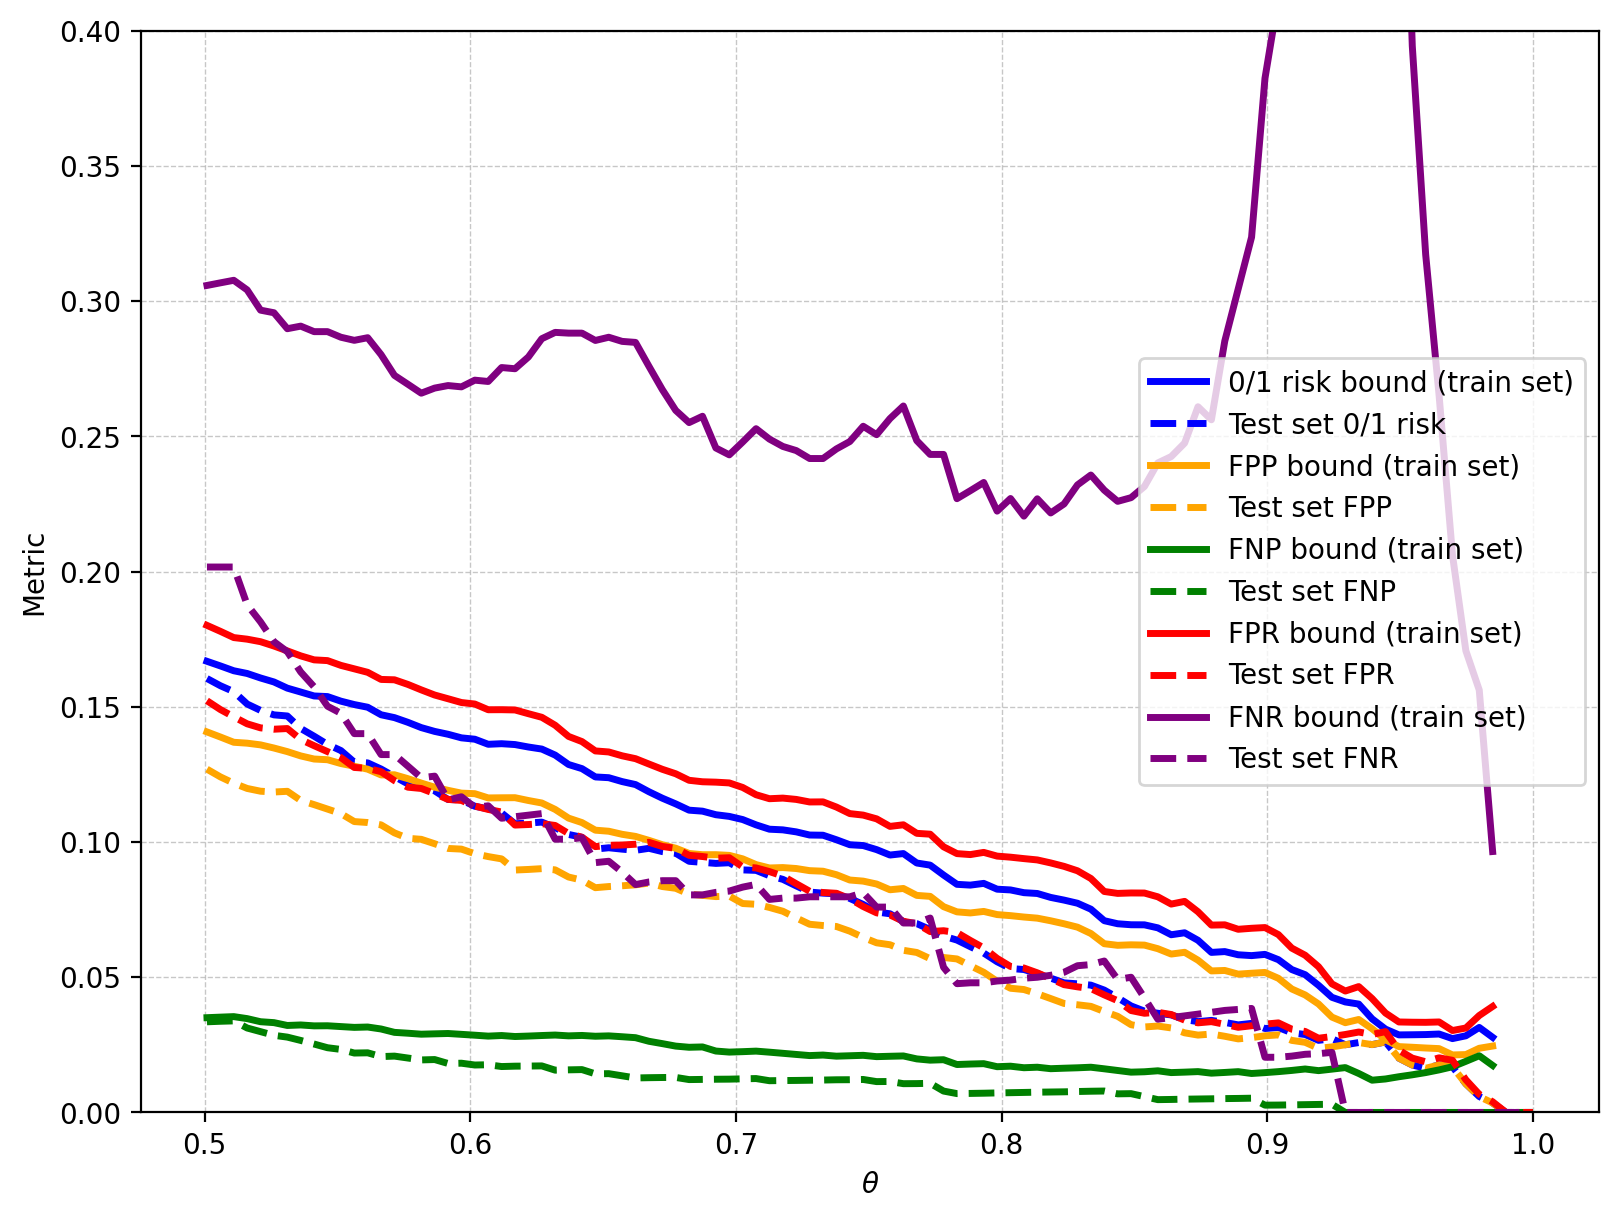

In [18]:
# Define a color map or list of colors for each metric
color_map = {
    'standard': 'blue',
    'FP': 'orange',
    'FN': 'green',
    'FPR': 'red',
    'FNR': 'purple'
}
label_map = {
    'standard': '0/1 risk',
    'FP': 'FPP',
    'FN': 'FNP',
    'FPR': 'FPR',
    'FNR': 'FNR'
}

plt.figure(figsize=(8, 6))

for metric in ['standard', 'FP', 'FN', 'FPR', 'FNR']:
    color = color_map[metric]
    
    thetas, bounds = bound_evo_w_theta(metric, train_set, delta, steps=100)
    plt.plot(thetas, bounds, color=color, label=label_map[metric]+' bound (train set)', linewidth=2.5)

    emp_metrics = []
    for theta in thetas:
        try:
            selected_set = test_set.loc[test_set.SR >= theta].copy()
            emp_metrics.append(emp_metric(selected_set, metric=metric))
        except ValueError:
            emp_metrics.append(np.nan)

    plt.plot(thetas, emp_metrics, linestyle='--', color=color, label='Test set ' + label_map[metric], linewidth=2.5)

plt.ylim(0, 0.4)
plt.tight_layout()
plt.xlabel(r'$\theta$')
plt.ylabel('Metric')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.show()

SE, PPV

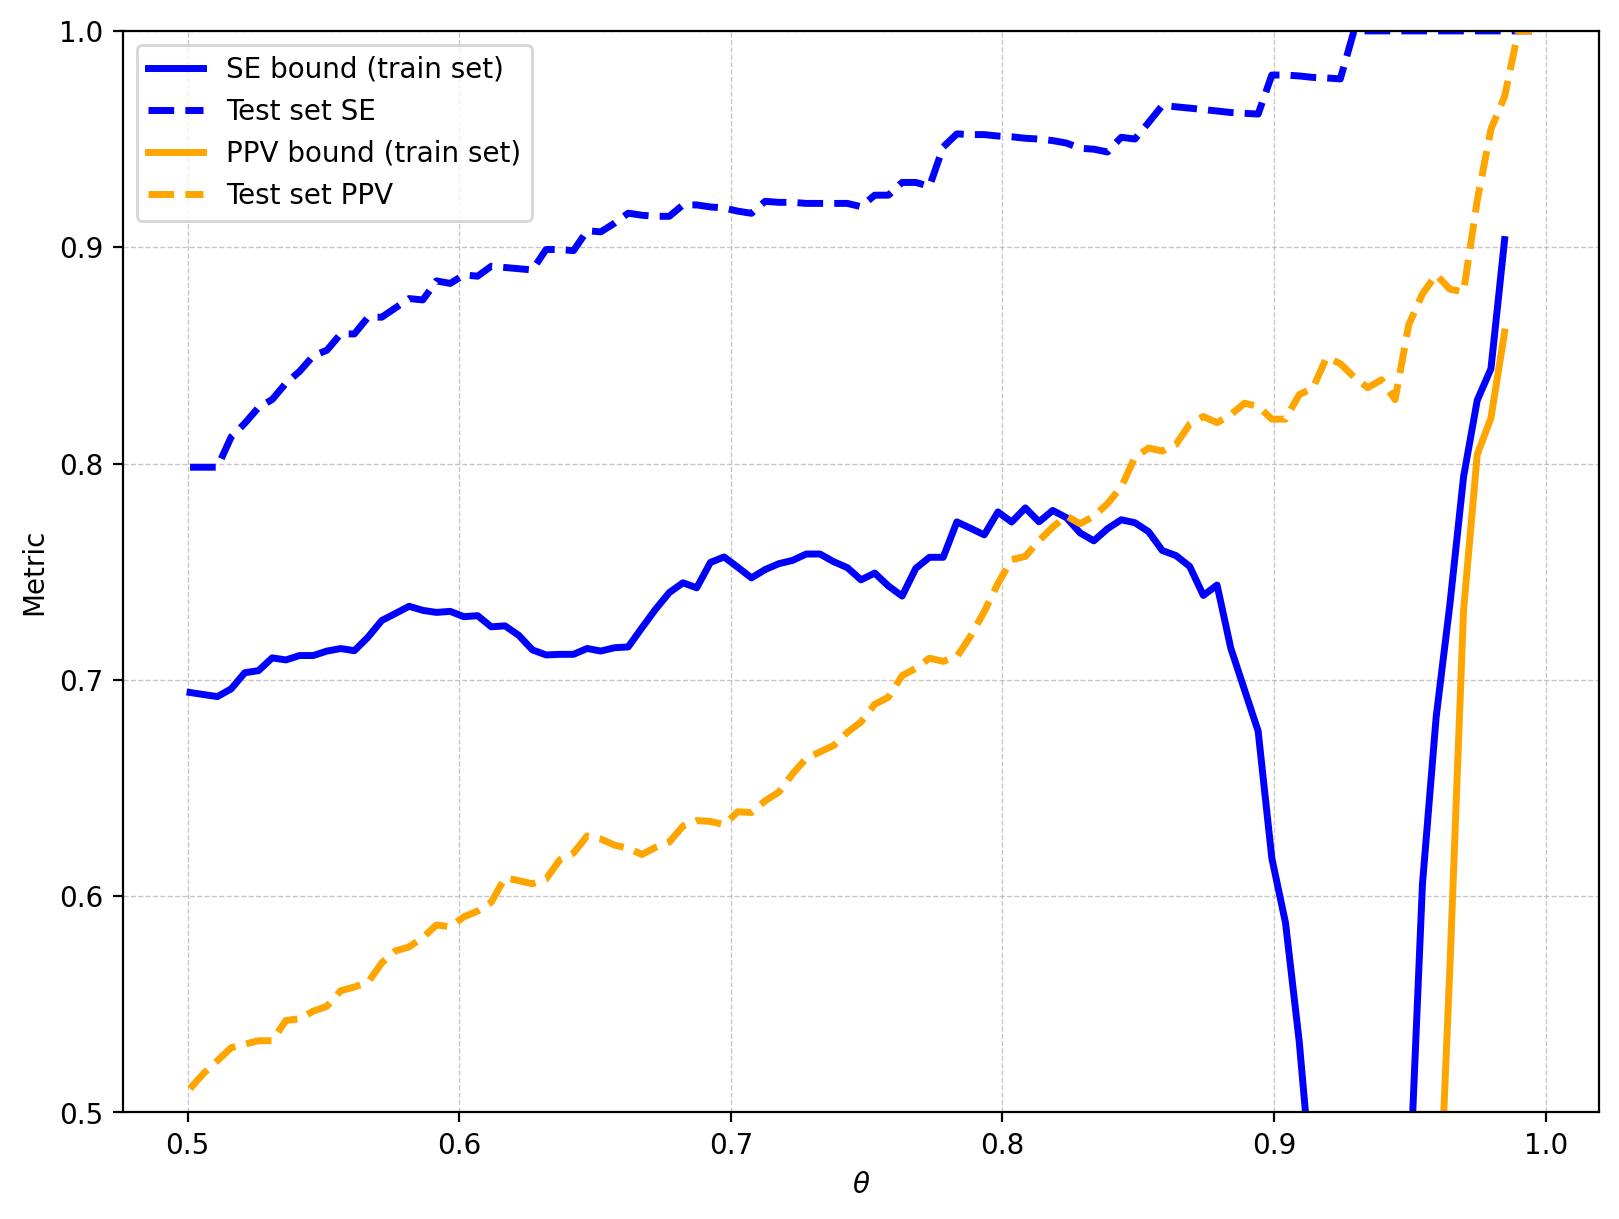

In [19]:
# Define a color map or list of colors for each metric
color_map = {
    'SE': 'blue',
    'PPV': 'orange'
}

plt.figure(figsize=(8, 6))

for metric in ['SE', 'PPV']:
    color = color_map[metric]
    
    thetas, bounds = bound_evo_w_theta(metric, train_set, delta, steps=100)
    plt.plot(thetas, bounds, color=color, label=metric+' bound (train set)', linewidth=2.5)

    emp_metrics = []
    for theta in thetas:
        try:
            selected_set = test_set.loc[test_set.SR >= theta].copy()
            emp_metrics.append(emp_metric(selected_set, metric=metric))
        except ValueError:
            emp_metrics.append(np.nan)

    plt.plot(thetas, emp_metrics, linestyle='--', color=color, label='Test set ' + metric, linewidth=2.5)

plt.ylim(0.5, 1)
plt.tight_layout()
plt.xlabel(r'$\theta$')
plt.ylabel('Metric')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.show()

### Find best $\theta$ in the intersection of metrics $\theta$ regions, if non empty

In [20]:
metrics_and_targets = {'standard' : 0.03,
                       'PPV' : 0.9,
                       'SE': 0.93}

In [21]:
joint_output = joint_control(metrics_and_targets, sgr_df, delta, plot=False)
joint_output

{'theta_intervals': [], 'best_theta': inf}

### All reachable bounds for a couple of metrics

In [23]:
metrics = ['standard', 'FP', 'FN', 'FPR',
           'FNR','PPV', 'SE','SP']

all_bounds = reachable_bounds(metrics, sgr_df, delta, steps=100)

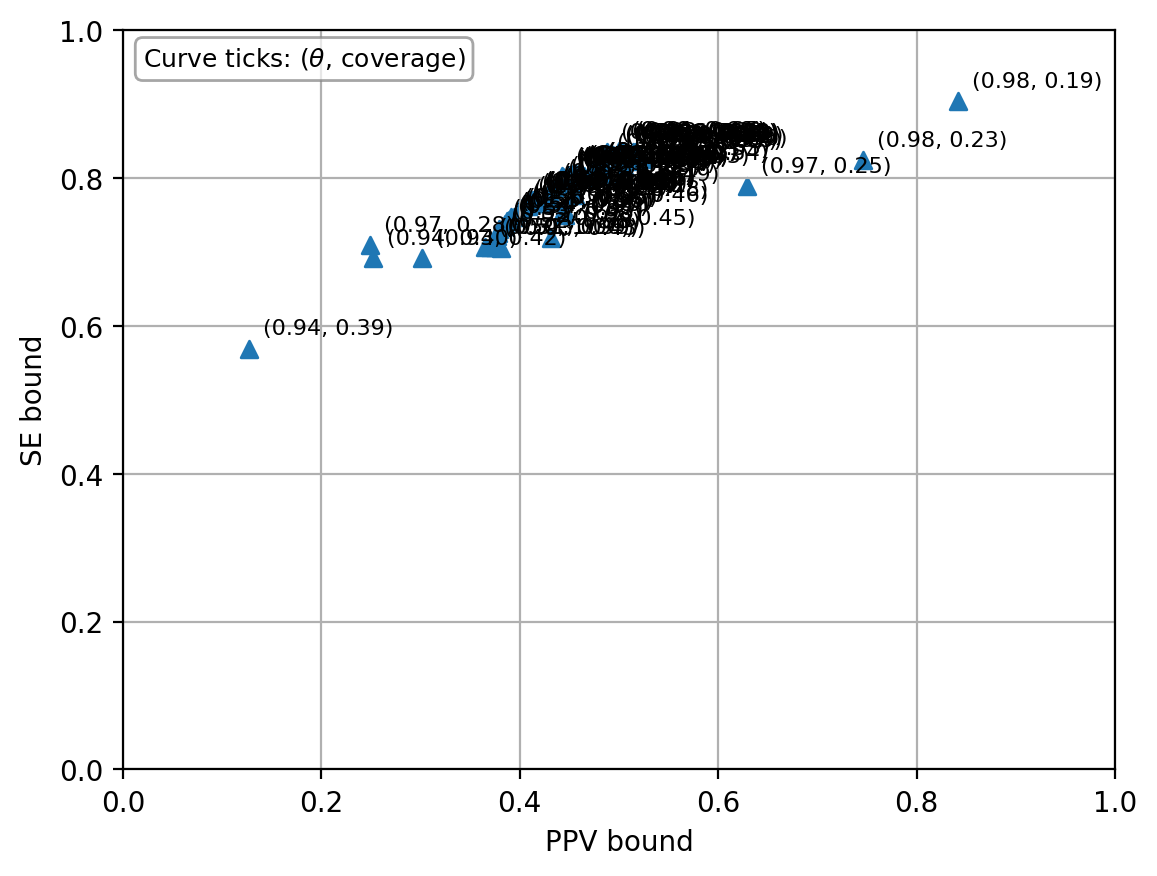

In [24]:
metric1 = 'PPV'
metric2 = 'SE'

x = all_bounds[metric1]
y = all_bounds[metric2]
labels = list(zip(all_bounds['thetas'], all_bounds['coverages']))

plt.scatter(x=x, y=y, marker='^')
plt.xlabel(metric1 + ' bound')
plt.ylabel(metric2 + ' bound')
plt.grid()

# Choose 10 evenly spaced indices along the curve
num_labels = 100
indices = np.linspace(0, len(x) - 1, num=num_labels, dtype=int)

for j in indices:
    label = f'({labels[j][0]:.2f}, {labels[j][1]:.2f})'
    plt.annotate(label, (x[j], y[j]), textcoords="offset points", xytext=(5,5), ha='left', fontsize=8)

# Add a single legend-like text to explain the annotations
plt.text(0.02, 0.98, r'Curve ticks: ($\theta$, coverage)',
         transform=plt.gca().transAxes,
         fontsize=9, verticalalignment='top', horizontalalignment='left',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.7))

plt.xlim(max(0,min(x))*0.99,1)
plt.ylim(max(0,min(y))*0.99,1)
plt.show()